# **Notebook 09: LIME Analysis**

## Objective:
Notebook 07 gave us global and local SHAP explanations. This notebook applies LIME (Local Interpretable Model-agnostic Explanations) to the same XGBoost model — giving us a second, independent explanation method to compare against.

## Why LIME alongside SHAP?
SHAP explains by calculating each feature's contribution mathematically across the whole model. LIME works differently — it perturbs individual instances and fits a simple local model around them. If both methods agree on the same top features, that's strong evidence the explanations are real, not artefacts of the method.

## We are aiming for...
- Local explanation for a high-risk patient
- Local explanation for a low-risk patient
- Aggregate LIME feature importance across 200 samples
- Direct SHAP vs LIME comparison
- All outputs saved for Notebook 11 (clinical validation framework)

In [1]:
# Cell 1 - Imports and Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')
!pip install lime
from lime import lime_tabular

print("Libraries loaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=9b9020183b10c452ca5573d16e350cf6206bd1dea9605083111d314ae0651573
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Libraries loaded.


In [2]:
# Cell 2 - Load final model and data
import pickle
from sklearn.preprocessing import LabelEncoder

xgb_model    = pickle.load(open('/content/xgboost_final_45f.pkl', 'rb'))
feature_cols = pickle.load(open('/content/final_feature_cols.pkl', 'rb'))
le_mappings  = pickle.load(open('/content/final_le_mappings.pkl', 'rb'))
split        = pickle.load(open('/content/final_split_indices.pkl', 'rb'))
train_end    = split['train_end']
val_end      = split['val_end']

df = pd.read_csv('/content/bq-results-20260323-203006-1774297820102.csv')

df['marital_status']     = df['marital_status'].fillna('UNKNOWN')
df['language']           = df['language'].fillna('UNKNOWN')
df['insurance']          = df['insurance'].fillna('UNKNOWN')
df['admission_location'] = df['admission_location'].fillna('UNKNOWN')
df['discharge_location'] = df['discharge_location'].fillna('UNKNOWN')
df['race']               = df['race'].fillna('UNKNOWN')

lab_cols = ['num_lab_tests_24h', 'num_abnormal_labs', 'hemoglobin_min',
            'wbc_max', 'creatinine_max', 'sodium_min', 'sodium_max',
            'potassium_min', 'potassium_max', 'glucose_min', 'glucose_max']
for col in lab_cols:
    df[col] = df[col].fillna(df[col].median())

hist_cols = ['days_since_last_discharge', 'num_admissions_last_30d',
             'num_admissions_last_90d', 'num_admissions_last_year',
             'total_prior_admissions', 'recent_admission_flag', 'frequent_flyer_flag']
for col in hist_cols:
    df[col] = df[col].fillna(0)

df = df.fillna(df.median(numeric_only=True))

categorical_cols = ['gender', 'race', 'marital_status', 'language', 'insurance',
                    'admission_location', 'discharge_location', 'admission_type']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

df['admittime'] = pd.to_datetime(df['admittime'])
df_sorted = df.sort_values('admittime').reset_index(drop=True)

X = df_sorted[feature_cols]
y = df_sorted['readmitted_30d']

X_train, y_train = X.iloc[:train_end],        y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:],          y.iloc[val_end:]

print(f"Model loaded: {xgb_model.n_features_in_} features")
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Test readmission rate: {y_test.mean():.4f}")

Model loaded: 45 features
Train: 284,221 | Val: 60,905 | Test: 60,905
Test readmission rate: 0.1800


In [5]:
# Cell 4 - Build LIME Explainer
categorical_features = [list(X_train.columns).index(c) for c in categorical_cols if c in X_train.columns]

categorical_names = {}
for col in categorical_cols:
    if col in X_train.columns:
        idx = list(X_train.columns).index(col)
        categorical_names[idx] = le_mappings[col]['classes']

explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_cols,
    class_names=['not readmitted', 'readmitted'],
    categorical_features=categorical_features,
    categorical_names=categorical_names,
    mode='classification',
    random_state=42
)

print(f"LIME explainer ready.")
print(f"Features: {len(feature_cols)}")
print(f"Categorical features declared: {len(categorical_features)}")
print(f"Sample categorical mapping — race[0]: {categorical_names[list(X_train.columns).index('race')][0]}")

LIME explainer ready.
Features: 45
Categorical features declared: 8
Sample categorical mapping — race[0]: AMERICAN INDIAN/ALASKA NATIVE


high risk patient predicted probability: 0.9694
actual label: 1

top features:
  cci_cancer <= 0.00: -0.0680
  num_admissions_last_year <= 0.00: -0.0680
  cci_dementia <= 0.00: 0.0513
  cci_cvd <= 0.00: 0.0459
  num_abnormal_labs <= 6.00: -0.0346
  num_admissions_last_90d <= 0.00: -0.0342
  antibiotic_flag <= 0.00: 0.0334
  num_lab_tests_24h <= 24.00: 0.0260
  race=WHITE: 0.0245
  insurance=UNKNOWN: -0.0209
  num_medications <= 14.00: -0.0193
  cci_mi <= 0.00: 0.0190
  50.00 < los_hours <= 90.00: -0.0189
  age <= 44.00: 0.0165
  cci_copd <= 0.00: 0.0160


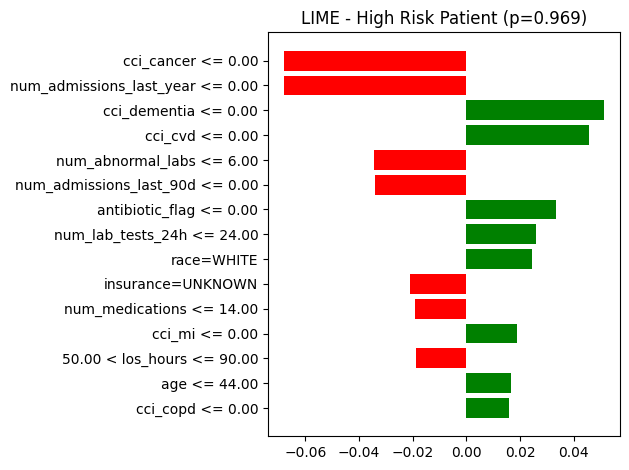

saved: lime_high_risk.png


In [6]:
# Cell 5 - Local Explanation: High Risk Patient

y_pred_proba = xgb_model.predict_proba(X_test.values)[:,1]
high_risk_idx = y_pred_proba.argmax()

exp_high = explainer.explain_instance(
    data_row=X_test.values[high_risk_idx],
    predict_fn=xgb_model.predict_proba,
    num_features=15
)

print(f"high risk patient predicted probability: {y_pred_proba[high_risk_idx]:.4f}")
print(f"actual label: {y_test.iloc[high_risk_idx]}")
print(f"\ntop features:")
for feat, weight in exp_high.as_list():
    print(f"  {feat}: {weight:.4f}")

fig = exp_high.as_pyplot_figure()
plt.title(f"LIME - High Risk Patient (p={y_pred_proba[high_risk_idx]:.3f})")
plt.tight_layout()
plt.savefig('/content/lime_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: lime_high_risk.png")

low risk patient predicted probability: 0.0346
actual label: 0

top features:
  discharge_location=HOSPICE: -0.2313
  marital_status=UNKNOWN: -0.1014
  race=UNABLE TO OBTAIN: -0.0981
  cci_cancer > 0.00: 0.0808
  num_admissions_last_year <= 0.00: -0.0748
  los_hours > 159.00: 0.0639
  cci_cvd > 0.00: -0.0462
  num_admissions_last_90d <= 0.00: -0.0373
  hemoglobin_min <= 10.00: 0.0350
  antibiotic_flag <= 0.00: 0.0349
  num_diagnoses > 17.00: 0.0322
  cci_dementia <= 0.00: 0.0291
  age > 72.00: -0.0283
  admission_type=OBSERVATION ADMIT: -0.0238
  cci_diabetes <= 0.00: 0.0236


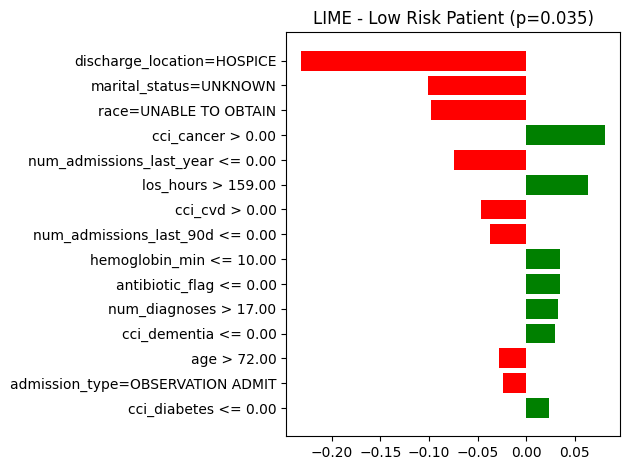

saved: lime_low_risk.png


In [7]:
# Cell 6 - Local Explanation: Low Risk Patient

low_risk_idx = y_pred_proba.argmin()

exp_low = explainer.explain_instance(
    data_row=X_test.values[low_risk_idx],
    predict_fn=xgb_model.predict_proba,
    num_features=15
)

print(f"low risk patient predicted probability: {y_pred_proba[low_risk_idx]:.4f}")
print(f"actual label: {y_test.iloc[low_risk_idx]}")
print(f"\ntop features:")
for feat, weight in exp_low.as_list():
    print(f"  {feat}: {weight:.4f}")

fig = exp_low.as_pyplot_figure()
plt.title(f"LIME - Low Risk Patient (p={y_pred_proba[low_risk_idx]:.3f})")
plt.tight_layout()
plt.savefig('/content/lime_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: lime_low_risk.png")

## **Analysis: Low Risk Patient (p=0.035)**

Three of the top five LIME features for this patient are clinically non-actionable:

**1. discharge_location=HOSPICE (-0.2313)** is the dominant driver.

- The model is statistically correct — hospice patients rarely get readmitted within 30 days. But this is not a modifiable risk factor. A clinician cannot intervene on a discharge destination that reflects end-of-life care. The explanation is valid, the insight is not.

**2. marital_status=UNKNOWN (-0.1014) and race=UNABLE TO OBTAIN (-0.0981)** are demographic missingness signals ranked 2nd and 3rd.

- The model learned that patients with undocumented demographics are lower risk in MIMIC-IV — which is true at a population level — but a clinician reviewing this explanation has no actionable pathway from "demographic data is missing."

- This patient also has **cci_cancer > 0** pushing risk upward (+0.0808), which the model overrides with the discharge_location(**hospice**) and missingness signals. A cancer patient being classified as low risk because their demographics weren't recorded and they were discharged to hospice(which we'll use as the kind of explanation that requires clinical validation before it influences care decisions).

I guess this case will directly motivate the clinical validation framework in Notebook 11(statistically faithful explanations are not the same as clinically useful ones).

Running LIME on 500 samples...
  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done
  500/500 done

UNKNOWN in top-3 features: 10/500 (5.0%)

Top 15 features by top-3 frequency:
Feature                                        Count      %
------------------------------------------------------------
cci_cancer <= 0.00                               454  90.8%
num_admissions_last_year <= 0.00                 270  54.0%
num_admissions_last_year > 1.00                  130  26.0%
cci_dementia <= 0.00                             122  24.4%
los_hours > 159.00                               107  21.4%
los_hours <= 50.00                                85  17.0%
cci_cvd <= 0.00                                   82  16.4%
antibiotic_flag <= 0.00                           50  10.0%
cci_cancer > 0.00                                 42   8.4%
num_admissions_last_90d > 1.00                    25   5.0%
0.00 < antibiotic_fl

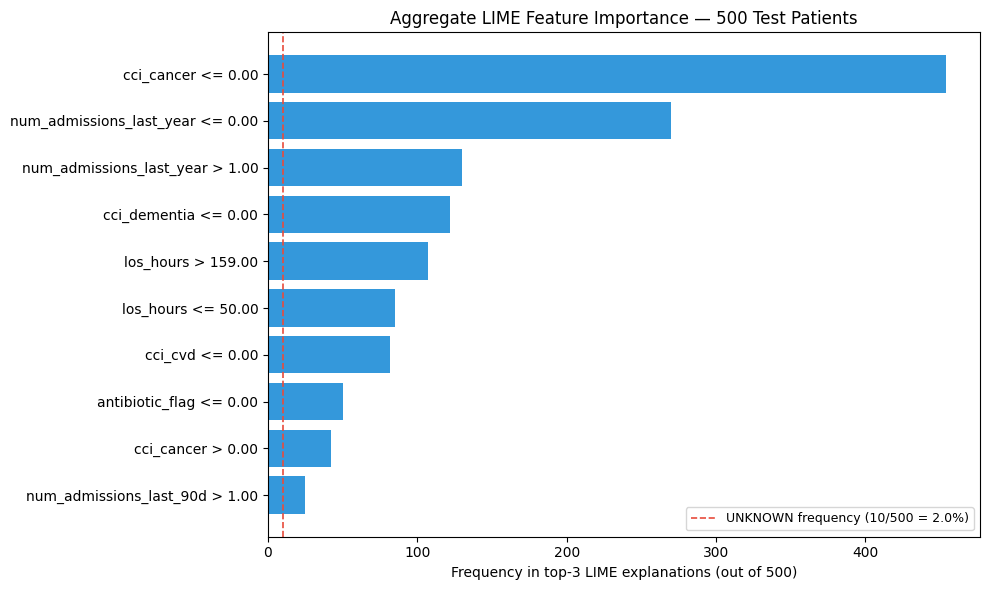

Saved: lime_aggregate.png


In [10]:
# Cell 7 - Aggregate LIME feature importance across 500 samples
from collections import defaultdict
import numpy as np

np.random.seed(42)
sample_idx = np.random.choice(len(X_test), 500, replace=False)

feature_weights  = defaultdict(list)
feature_top3     = defaultdict(int)
unknown_in_top3  = 0

print("Running LIME on 500 samples...")
for i, idx in enumerate(sample_idx):
    exp = explainer.explain_instance(
        data_row=X_test.values[idx],
        predict_fn=xgb_model.predict_proba,
        num_features=10
    )
    top_features = exp.as_list()
    top3_names   = [f[0] for f in top_features[:3]]

    for feat, weight in top_features:
        feature_weights[feat].append(abs(weight))

    for feat in top3_names:
        feature_top3[feat] += 1

    if any('UNKNOWN' in f for f in top3_names):
        unknown_in_top3 += 1

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/500 done")

print(f"\nUNKNOWN in top-3 features: {unknown_in_top3}/500 ({unknown_in_top3/2:.1f}%)")

top_features_sorted = sorted(feature_top3.items(), key=lambda x: x[1], reverse=True)[:15]
print(f"\nTop 15 features by top-3 frequency:")
print(f"{'Feature':<45} {'Count':>6} {'%':>6}")
print("-" * 60)
for feat, count in top_features_sorted:
    print(f"{feat:<45} {count:>6} {count/500*100:>5.1f}%")

import matplotlib.pyplot as plt
labels  = [f[0][:40] for f in top_features_sorted[:10]]
counts  = [f[1] for f in top_features_sorted[:10]]
colors  = ['#e74c3c' if 'UNKNOWN' in l else '#3498db' for l in labels]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels[::-1], counts[::-1], color=colors[::-1])
ax.set_xlabel('Frequency in top-3 LIME explanations (out of 500)')
ax.set_title('Aggregate LIME Feature Importance — 500 Test Patients')
ax.axvline(x=unknown_in_top3, color='#e74c3c', linestyle='--', linewidth=1.2,
           label=f'UNKNOWN frequency ({unknown_in_top3}/500 = {unknown_in_top3/5:.1f}%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/content/lime_aggregate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lime_aggregate.png")

In [11]:
# Cell 8 - SHAP vs LIME comparison on low risk patient
import shap

explainer_shap  = shap.TreeExplainer(xgb_model)
shap_values_lr  = explainer_shap.shap_values(X_test.iloc[[low_risk_idx]])

shap_top = sorted(zip(feature_cols, shap_values_lr[0]),
                  key=lambda x: abs(x[1]), reverse=True)[:10]

lime_top = exp_low.as_list()[:10]

print("SHAP vs LIME — Same Low Risk Patient")
print(f"Predicted probability: {y_pred_proba[low_risk_idx]:.4f}")
print(f"\n{'SHAP Top 10':<40} {'LIME Top 10'}")
print("-" * 85)
for i in range(10):
    shap_feat = f"{shap_top[i][0]}: {shap_top[i][1]:+.4f}" if i < len(shap_top) else ""
    lime_feat = f"{lime_top[i][0]}: {lime_top[i][1]:+.4f}" if i < len(lime_top) else ""
    print(f"{shap_feat:<40} {lime_feat}")

shap_top5_names = {f[0] for f in shap_top[:5]}
lime_top5_names = set()
for feat, _ in lime_top[:5]:
    for col in feature_cols:
        if col in feat:
            lime_top5_names.add(col)

overlap = shap_top5_names & lime_top5_names
print(f"\nTop-5 feature overlap between SHAP and LIME: {len(overlap)}/5")
print(f"Overlapping features: {overlap}")

SHAP vs LIME — Same Low Risk Patient
Predicted probability: 0.0346

SHAP Top 10                              LIME Top 10
-------------------------------------------------------------------------------------
discharge_location: -1.3866              discharge_location=HOSPICE: -0.2313
race: -0.5365                            marital_status=UNKNOWN: -0.1014
marital_status: -0.4735                  race=UNABLE TO OBTAIN: -0.0981
age: -0.3974                             cci_cancer > 0.00: +0.0808
cci_cvd: -0.2249                         num_admissions_last_year <= 0.00: -0.0748
num_admissions_last_year: -0.1860        los_hours > 159.00: +0.0639
num_admissions_last_90d: -0.0955         cci_cvd > 0.00: -0.0462
cci_cancer: +0.0886                      num_admissions_last_90d <= 0.00: -0.0373
cci_copd: -0.0573                        hemoglobin_min <= 10.00: +0.0350
hemoglobin_min: +0.0538                  antibiotic_flag <= 0.00: +0.0349

Top-5 feature overlap between SHAP and LIME: 3/5
Overla

## SHAP vs LIME: Method Comparison on Low Risk Patient

- Both methods agree on the top 3 features: discharge_location, race, and marital_status, all non-actionable. That convergence is significant. When two independent explanation methods built on entirely different mathematical foundations surface the same features, the explanation is unlikely to be a methodological artefact.

- The divergence is equally informative. SHAP ranks age as the 4th most influential feature (-0.3974) while LIME does not surface it in the top 10. SHAP and LIME also disagree on the direction of cci_cvd, SHAP assigns it a negative contribution while LIME assigns a positive one. This reflects a known limitation of LIME: its local linear approximation can misrepresent feature directionality for non-linear models, particularly for features with threshold effects.

- The 3/5 overlap confirms methodological consistency on the features that matter most for this thesis. The divergence on age and cci_cvd is a concrete example of why relying on a single XAI method for clinical decisions is insufficient, which is precisely what the validation framework in Notebook 11 is designed to address.

# NB09 — Conclusions & Key Takeaways

- LIME on 500 test patients tells a consistent story: the model's local explanations are overwhelmingly driven by clinical features. cci_cancer absence dominates 90.8% of explanations, prior admission history appears in over 54%, these are exactly the features clinical literature would predict as readmission drivers.

- The non-actionable signal is real but isolated. Demographic missingness (race=UNKNOWN, marital_status=UNKNOWN) appears in top-3 explanations for 2.0% of patients (10/500). discharge_location=HOSPICE appears at the same rate i.e., 2.0%. Together, roughly 4% of local explanations surface features that a clinician cannot act on. That is not a systemic failure of the model, but it is a failure mode that clinical validation must catch.

- The SHAP vs LIME comparison on the low-risk patient confirmed methodological consistency where it matters most, both methods independently ranked discharge_location, race, and marital_status as the top three drivers. The disagreement on age and cci_cvd direction is a known limitation of LIME's linear approximation on non-linear models, and a concrete reason why single-method XAI evaluation is insufficient for clinical deployment.

- The hospice case is the strongest finding in this notebook. A cancer patient discharged to hospice being classified as low readmission risk because of demographic missingness and end-of-life discharge patterns is statistically defensible and clinically misleading simultaneously. That gap is what Notebook 11's clinical validation framework exists to address.